# Using Conditional Conformal Prediction to get adaptative prediction intervals
## Tutorial and comparison with other methods on <i>"Communities and Crimes"</i> Dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/scikit-learn-contrib/MAPIE/blob/master/notebooks/regression/tutorial_ccp_CandC.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from tqdm import tqdm
from urllib.request import urlopen
from sklearn.base import clone
from copy import deepcopy

from lightgbm import LGBMRegressor
from mapie.conformity_scores import AbsoluteConformityScore
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.base import clone

from mapie.conditional_conformal_prediction import ConditionalSplitConformalRegressor
from mapie.regression import (
    ConformalizedQuantileRegressor,
    SplitConformalRegressor,
)

import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning)

random_state = 1
np.random.seed(random_state)

## Getting the data

In [2]:
with urlopen("https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.names", timeout=30) as response:
    names_text = response.read().decode("latin-1")
column_names = [
    line.strip().split()[1]
    for line in names_text.splitlines()
    if line.strip().startswith("@attribute")
]
communities_and_crime = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/communities/communities.data", names=column_names, na_values="?")
y = communities_and_crime["ViolentCrimesPerPop"].to_numpy()
X = communities_and_crime.drop(columns=["communityname", "ViolentCrimesPerPop"])
X = X.loc[:, X.isna().sum() == 0]
col_names = list(X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.to_numpy())

We normalize the data, to simplify the following (even if the used model doesn't requires it)

In [3]:
def generate_data(seed, n_train, n_calib, n_test):
    """
    Return a new split (x_train, y_train, x_calib, y_calib, x_test, y_test)
    of the dataset, based on the ``seed`` value.
    """
    np.random.seed(seed)
    if n_train+n_calib+n_test > len(X):
        raise ValueError(
            f"n_train + n_calib + n_test = {n_train} + {n_calib} + {n_test}"
            f" = {n_train+n_calib+n_test} > len(total_dataset) = {len(X)}")
    
    indexes = list(range(len(X)))
    train_indexes = np.random.choice(indexes, n_train, replace=False)
    indexes = list(set(indexes) - set(train_indexes))
    calib_indexes = np.random.choice(indexes, n_calib, replace=False)
    indexes = list(set(indexes) - set(calib_indexes))
    test_indexes = np.random.choice(indexes, n_test, replace=False)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X_scaled[train_indexes,:], y[train_indexes], X_scaled[calib_indexes,:], y[calib_indexes], X_scaled[test_indexes,:], y[test_indexes]

## The goal:

- We will try to have an adaptative prediction interval using the ``CCP`` method (using ``CCPCalibrator``). We will compare it with standard ``Split`` CP (``MapieRegressor`` with ``method='base'``), and ``CQR`` (with ``MapieQuantileRegressor``).

- The adaptativity will be evaluated by looking at the conditional coverage over groups of target values, and groups on features of interest.

- The groups are the 10 target groups (see the histogram below), and the 4 quantiles (with thresholds at Q1, Q2 and Q3) on features of interest (``'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp'``).
Those features were chosen to make sure there is no bias toward one or the other ethnicity. 

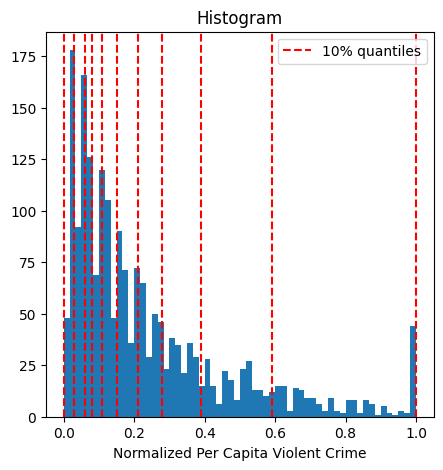

In [4]:
thres = [0] + [round(x, 2) for x in np.sort(y)[[int(len(y)/10*i) for i in range(1,10)]]] + [1]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for t in thres:
    ax.axvline(t, linestyle="--", c="r", label="10% quantiles"*int(t==0))
ax.hist(y, bins=60)
ax.set_xlabel("Normalized Per Capita Violent Crime")
ax.set_title("Histogram")
ax.legend()
plt.show()

By doing so, we create 10 groups based on the target value, where each group has the same number of samples.

## Evaluation functions

In [5]:
def estimate_scores(mapie_regressors, group_functions, score_functions,
                    n_train=2000,n_calib=2000,n_test=500, seed=1):
    """
    Sample a new data split, train the estimator on the training set, then
    fit the calibration on the new calibration set. The scores corresponding
    to ``score_functions`` are computing on each group of ``group_functions``.
    """
    
    x_train, y_train, x_calib, y_calib, x_test, y_test = generate_data(
        seed=seed,
        n_train=n_train,n_calib=n_calib,n_test=n_test
    )   
    scores = np.zeros((3, len(score_functions), len(group_functions)))
    for i, mapie_regressor in enumerate(mapie_regressors):
        mapie_regressor = deepcopy(mapie_regressor)
        mapie_regressor.fit(x_train, y_train).conformalize(x_calib, y_calib)
        _, y_pi = mapie_regressor.predict_interval(x_test)
        for group_num, group_fn in enumerate(group_functions):
            x_filter = group_fn(x_test, y_test)
            for score_num, score_fn in enumerate(score_functions):
                scores[i,score_num, group_num] = score_fn(
                    y=y_test[x_filter],
                    lower=y_pi[:, 0, 0][x_filter],
                    upper=y_pi[:, 1, 0][x_filter]
                )
    
    return scores


def get_scores_n_trials(
        mapies, n_trials, group_functions, group_names,
        score_functions, score_names, n_train=2000, n_calib=2000, n_test=500,
    ):
    """
    Compute ``n_trials`` evaluation scores on different dataset splits.
    """

    scores = np.zeros((n_trials, 3, len(score_functions), len(group_functions)))

    for trial in tqdm(range(n_trials)):
        scores[trial,:,:,:] = estimate_scores(
            mapies, group_functions, score_functions,
            n_train, n_calib, n_test, trial
        )
        
    method_names = ["Split", "CQR", "CCP"]
    
    scores_df = pd.DataFrame()
    for group_num, group_name in enumerate([e for g in  group_names for e in g]):
        for method_num, method_name in enumerate(method_names):
            temp_df = pd.DataFrame(
                {
                    'Method': [method_name] * n_trials, 
                    'Group name' : [group_name] * n_trials, 
                }
            )
            for score_num, score_name in enumerate(score_names):
                temp_df[score_name] = scores[:,method_num, score_num, group_num]    

            scores_df = pd.concat([scores_df,temp_df], axis=0)
            
    return scores_df.reset_index(drop=True)

## Plotting functions

In [6]:
def plot_subplot(ax, y_test_sorted, y_pred_sorted, upper_pi, lower_pi, lw,
                 color_rgb, xlabel, ylabel, title, showlegend=False):
    color = mcolors.rgb2hex(color_rgb)
    ax.plot(y_test_sorted, y_pred_sorted, lw=lw, color='black', label="Prediction" if showlegend else "")
    ax.fill_between(y_test_sorted, upper_pi, lower_pi, color=color, alpha=0.3, label='Prediction interval' if showlegend else "")
    ax.plot(y_test_sorted, upper_pi, lw=lw, color=color)
    ax.plot(y_test_sorted, lower_pi, lw=lw, color=color)
    ax.plot([0, 1], [0, 1], lw=lw, color='black', linestyle='--', label="Perfect Prediction" if showlegend else "")
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


def plot_score_boxplot(ax, df, score_name, group_names, color_discrete_map):
    flatten_group_names = [item for sub in group_names for item in sub]
    for i, method in enumerate(["Split", "CQR", "CCP"]):
        df_method = df[df["Method"] == method]
        color = color_discrete_map[method]
        
        ax.boxplot(
            [df_method[df_method["Group name"] == g][score_name] for g in flatten_group_names],
            positions=np.arange(len(flatten_group_names)) + (i-1) * 0.2,
            widths=0.2, patch_artist=True,
            boxprops=dict(facecolor=color), medianprops=dict(color="black"),
            labels=[g if i == 1 else "" for g in flatten_group_names]
        )

    for g in group_names[1:]:
        ax.axvline(x=flatten_group_names.index(g[0]) - 0.5, color='black', linewidth=2)
    ax.tick_params(axis='x', rotation=-45)
    ax.set_xticks(np.arange(len(flatten_group_names)))
    ax.set_xticklabels(flatten_group_names, ha='left', rotation_mode='anchor')


In [7]:
def plot_intervals(mapie_regressors, n_train, n_calib, n_test):
    x_train, y_train, x_calib, y_calib, x_test, y_test = generate_data(seed=1, n_train=n_train, n_calib=n_calib, n_test=n_test)

    sort_order = np.argsort(y_test)
    x_test_sorted = x_test[sort_order, :]
    y_test_sorted = y_test[sort_order]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for i, mapie_regressor in enumerate(mapie_regressors):
        mapie_regressor = deepcopy(mapie_regressor)
        mapie_regressor.fit(x_train, y_train).conformalize(x_calib, y_calib)
        y_pred_split, y_pis_split = mapie_regressor.predict_interval(x_test_sorted)
        split_lower = y_pis_split[:, 0, 0]
        split_upper = y_pis_split[:, 1, 0]
        plot_subplot(axes[i], y_test_sorted, y_pred_split, split_upper, split_lower, 1, f"C{i}", "True Price", "Predicted Price", "Split", showlegend=True)
        
        lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
        lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
        fig.legend(lines, labels, loc="upper right")

    plt.subplots_adjust(top=0.95, right=0.9)
    plt.show()
    
def plot_coverage_width(mapie_regressors, n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test):

    scores_df = get_scores_n_trials(mapie_regressors, n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test)
    # ============================ Plot results ============================
    for score_name in score_names:
        fig, ax = plt.subplots(figsize=(30, 10))
        cp = plt.get_cmap('tab10').colors
        color_discrete_map = dict(zip(["Split", "CQR", "CCP"], [mcolors.rgb2hex(c) for c in cp[:3]]))

        plot_score_boxplot(ax, scores_df, score_name, group_names, color_discrete_map)

        if score_name == "Coverage":
            ax.axhline(confidence_level, color='red', linewidth=3)

        ax.set_title(score_name, fontsize=22)
        ax.set_xlabel("Groups", fontsize=20)
        ax.set_ylabel(score_name, fontsize=20)
        ax.tick_params(axis='both', which='major', labelsize=20)
        
        legend_handles = [mpatches.Patch(color=color, label=method) for method, color in color_discrete_map.items()]
        fig.legend(handles=legend_handles, loc='upper right', fontsize=18)

        plt.tight_layout()
        plt.show()

## Evaluation methods and configuration

In [8]:
# scores functions
def coverage_funct(y, lower, upper):
    return np.mean((lower <= y) & (y <= upper))
def width_funct(y, lower, upper):
    return np.mean(np.abs(upper - lower))
score_functions = [coverage_funct, width_funct]
score_names = ["Coverage", "Width"]

# Groups functions: the scores will be evaluated on each one of these groups.
thres = thres = [0] + [round(x, 2) for x in np.sort(y)[[int(len(y)/10*i) for i in range(1,10)]]] + [1]

# index of the 4 columns of interest:
# 'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp'
group_cols = [4, 5, 6, 7]

group_functions = (
    # all dataset, for marginal evaluation
    [lambda x, y: np.ones(len(x)).astype(bool)]
    # 10 target groups
    + [lambda x, y, i=i : np.logical_and(y>=thres[i],  y <= thres[i+1]) for i in range(10)]
    # groups on ethnicity features
    + [lambda x, y, c=c, q1=q1, q2=q2 : np.logical_and(
        x[:, c] >= np.sort(X_scaled[:,c])[int(len(X_scaled)*q1)],
        x[:, c] <= np.sort(X_scaled[:,c])[int(len(X_scaled)*q2)-1])
        for c in group_cols
        for (q1, q2) in zip([0, 0.25, 0.5, 0.75], [0.25, 0.5, 0.75, 1])
    ]
)
group_names = (
    [["MARGINAL"]] 
    + [[f"Crime: {thres[i]} - {thres[i+1]}" for i in range(10)]]
    + [
        [
            f"{col_names[c]} : {q1}-{q2}%" 
            for (q1, q2) in zip([0, 25, 50, 75], [25, 50, 75, 100])
        ]
        for c in group_cols
    ]
)


## Model used for predictions

In [9]:
# Define the model
estimator = LGBMRegressor(
    objective='quantile',
    alpha=0.5,
    random_state=random_state,
    verbose=-1,
)

# # Define the parameter grid
# param_grid = {
#     'learning_rate': [0.05, 0.1, 0.2],
#     'max_depth': [8, 12, 16],
#     'n_estimators': [50, 100, 150, 200],
#     'num_leaves': [14, 21, 28, 35]
# }

# # Setup the RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator,
#     param_distributions=param_grid,
#     n_iter=30,
#     cv=5,
#     n_jobs=-1,
#     scoring='neg_mean_absolute_error',
#     random_state=random_state
# )

# # Perform the random search
# random_search.fit(X_scaled, y)

# # Print the best parameters and the corresponding score
# print("Best parameters found: ", random_search.best_params_)
# print("Best cross-validation score: ", -random_search.best_score_)

# estimator = random_search.best_estimator_



# Experiments and results:

In [10]:
confidence_level = 0.8
n_train, n_calib, n_test = 650, 650, 300
n_trials = 10

# PredefinedSplit is used to make sure that each method is trained
# and calibrated on the same data, to have a fair comparison
cv = PredefinedSplit([-1]*n_train + [1]*n_calib)

# ================= Split =================
mapie_split = SplitConformalRegressor(
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
    conformity_score=AbsoluteConformityScore(sym=False),
    prefit=False,
)

# ================= CQR =================
mapie_cqr = ConformalizedQuantileRegressor(
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
)

---

## 1. Using ``GaussianCCP`` calibrator for adaptativity <u>without prior knowledge on the dataset or biases</u>

In [11]:
def make_gaussian_ccp_feature_map(n_centers=40, sigma=7, seed=None):
    rng = np.random.default_rng(seed)
    centers = None

    def feature_map(X):
        nonlocal centers
        X = np.asarray(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        # First call is during conformalize(X_calib, y_calib), so this
        # reproduces GaussianCCP(40): sample centers from calibration X.
        if centers is None:
            center_idx = rng.choice(len(X), size=n_centers, replace=False)
            centers = X[center_idx]

        squared_distances = ((X[:, None, :] - centers[None, :, :]) / sigma) ** 2
        features = np.exp(-0.5 * squared_distances.sum(axis=2))

        # GaussianCCP default was normalized=True, bias=False.
        norms = np.linalg.norm(features, axis=1, keepdims=True)
        features[norms[:, 0] == 0] = 1
        norms[norms == 0] = 1
        return features / norms

    return feature_map
mapie_ccp = ConditionalSplitConformalRegressor(
    make_gaussian_ccp_feature_map(n_centers=40, sigma=7, seed=None),
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
    conformity_score=AbsoluteConformityScore(sym=False),
    prefit=False,
)

### Plotting the result

INFO:root:The predictions are ill-sorted.


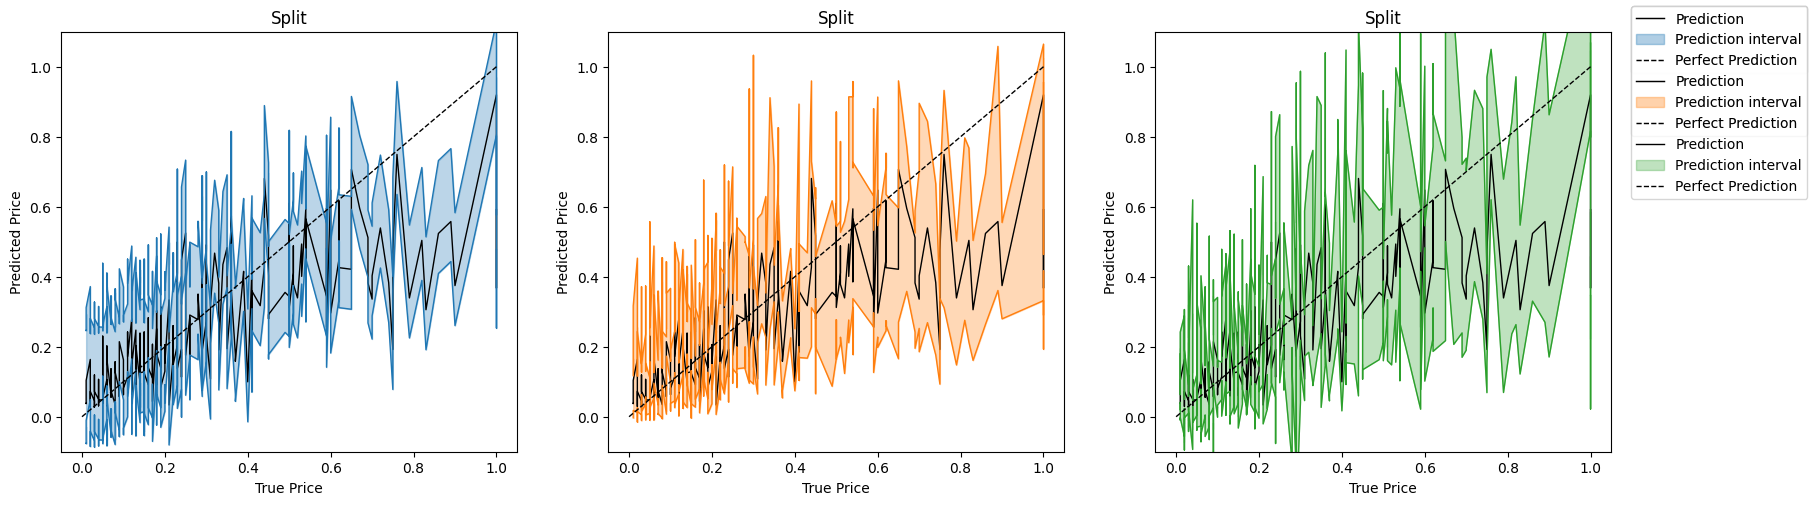

 20%|██        | 2/10 [00:13<00:49,  6.23s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 30%|███       | 3/10 [00:21<00:49,  7.04s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 40%|████      | 4/10 [00:27<00:39,  6.62s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 70%|███████   | 7/10 [00:47<00:20,  6.89s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 80%|████████  | 8/10 [00:53<00:13,  6.55s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 90%|█████████ | 9/10 [00:58<00:06,  6.16s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
100%|██████████| 10/10 [01:03<00:00,  6.37s/it]


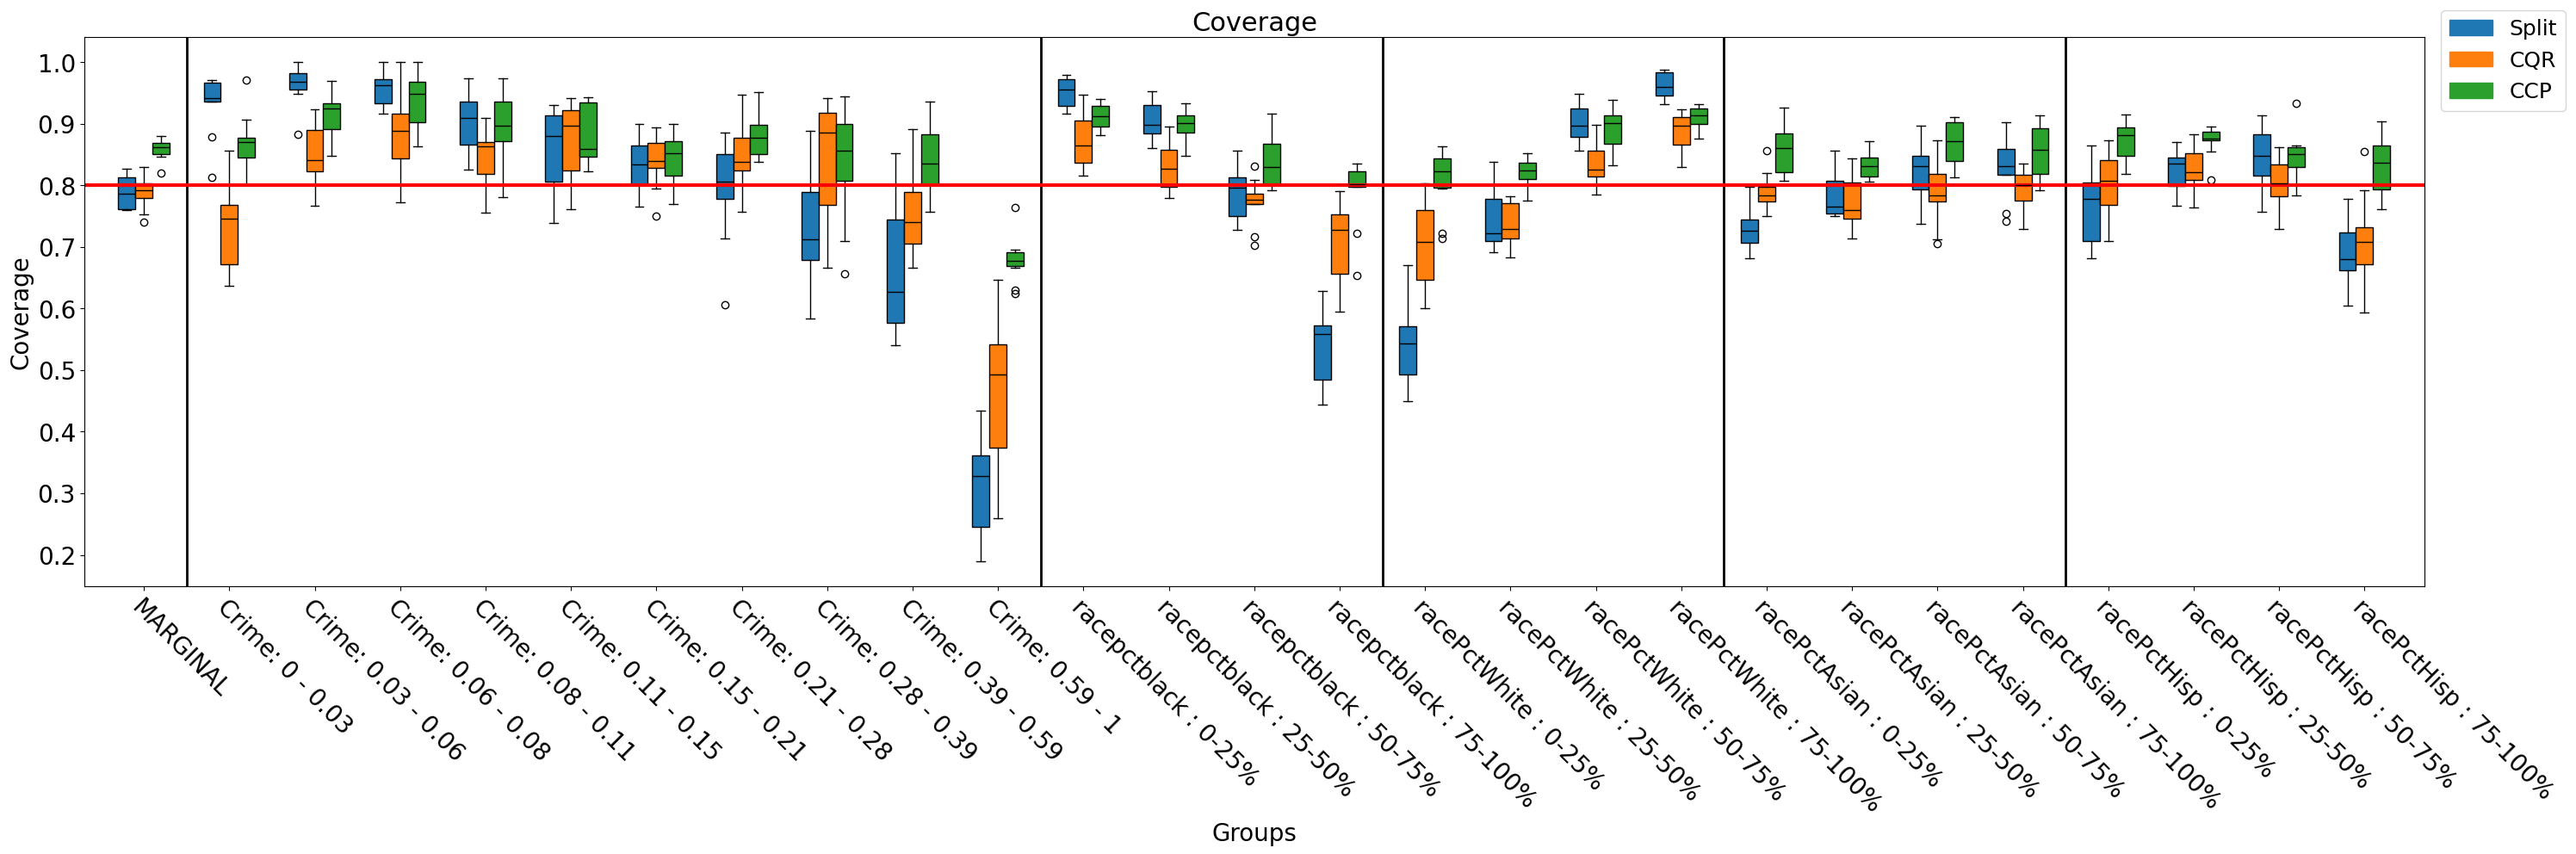

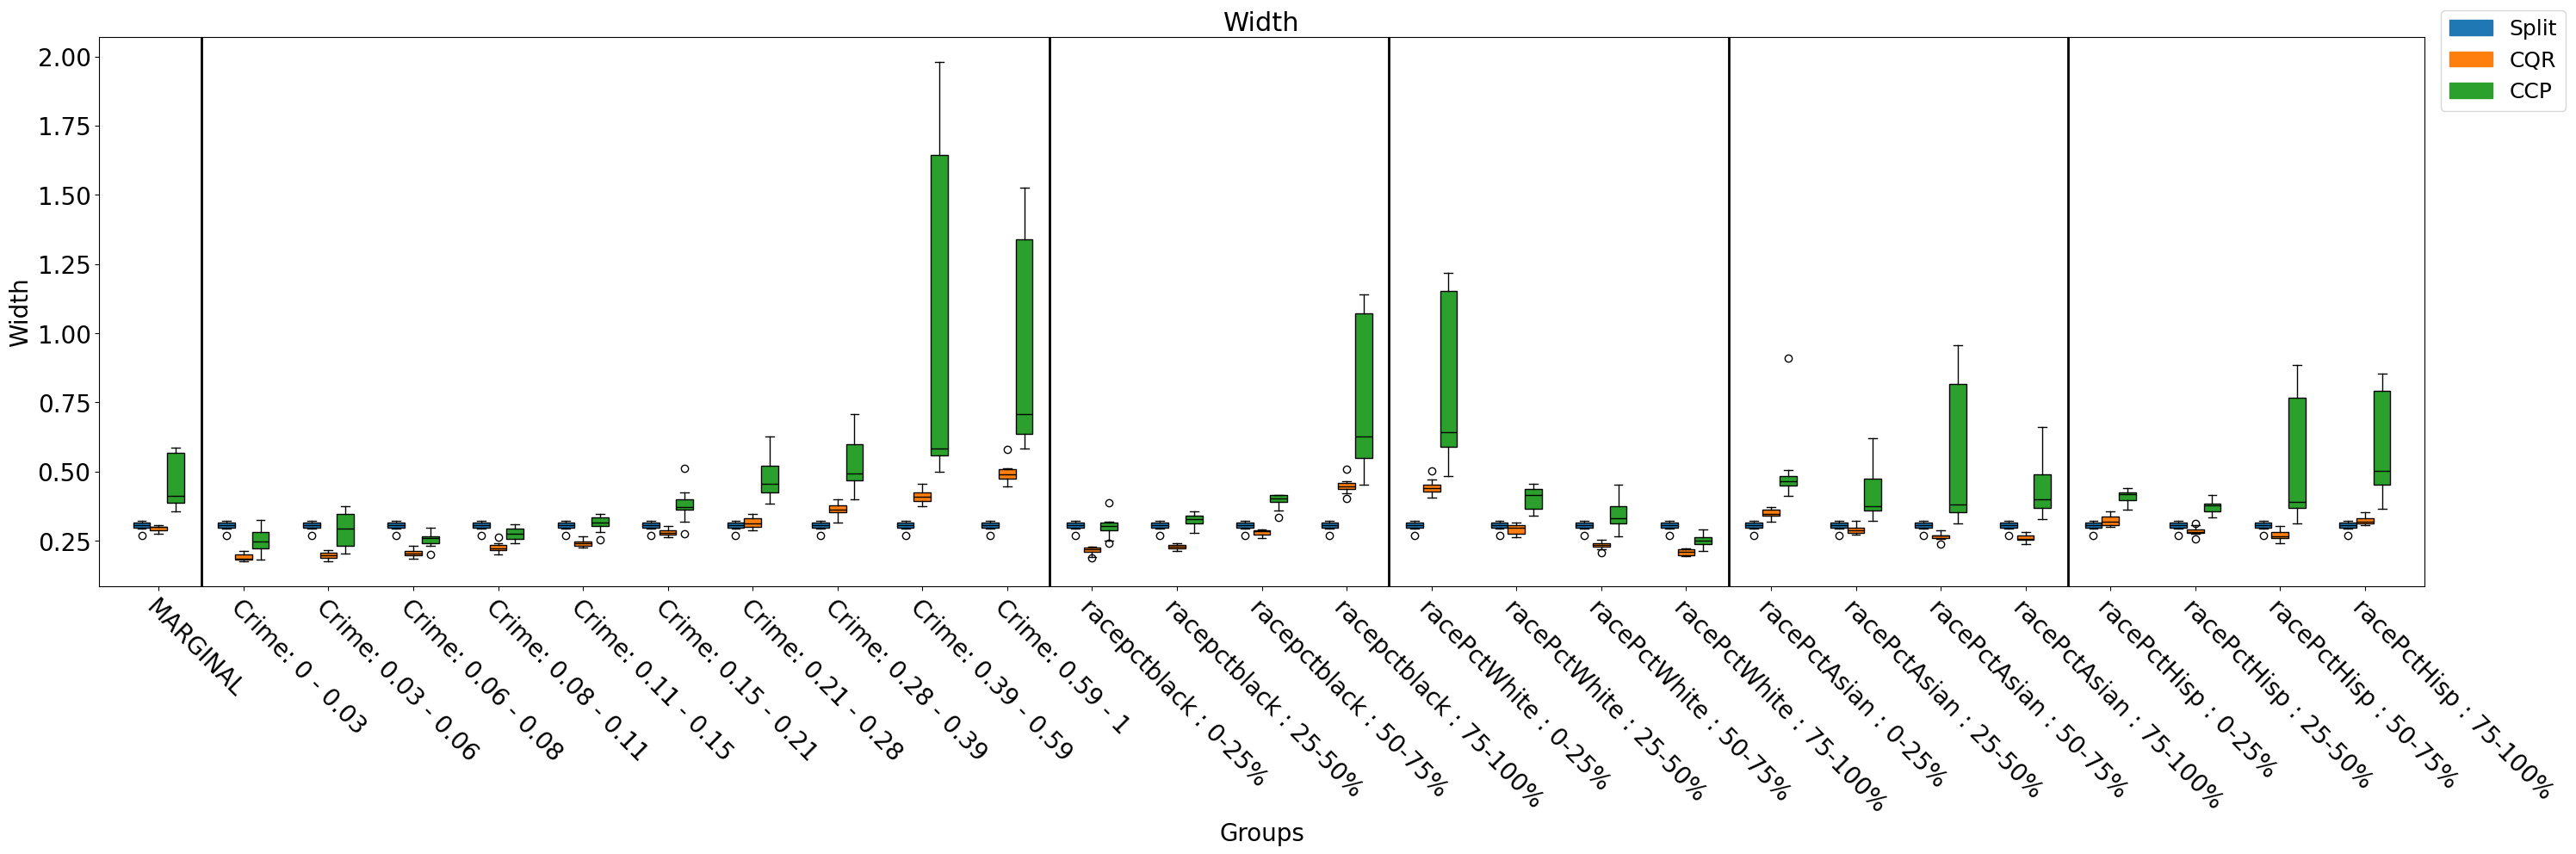

In [12]:
plot_intervals((mapie_split, mapie_cqr, mapie_ccp), n_train, n_calib, n_test)
plot_coverage_width((mapie_split, mapie_cqr, mapie_ccp), n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test)

- The method which is the more adaptative is the one with the most constant coverage.
- Here, the ``CCP`` method is the best one. We can see that the basic ``Split`` method has a strong over-coverage for small target values, and under-coverage for big target values. Moreover, it seems to have a <u>strong bias</u> on the ``'racepctblack'`` and ``'racePctWhite'``.
- The ``CQR`` method is better than the ``Split`` but suffers from the same issues.

$\to$ We managed, with the ``CCP`` method, to have almost a <u>homogenous coverage</u> on the target value, and a much <u>smaller bias on the ethnicity groups</u>.

$\to$ However:
- the ``CCP`` method needs few iterations (or cross-val optimisation) to find the best parameters (especially for ``sigma``)
- its calibration is much longer than the other CP methods. The computational time can increase a lot if you have a lot of calibration points and if you use a lot of dimensions in the calibrator (here, we used ``40``).

---

## 2. Using ``CustomCCP`` calibrator for adaptativity <u>with prior knowledge about the biases</u> we want to avoid
We saw previously, that there was a strong bias on the ethnicity features (with over or under coverage for some values).

$\to$ We can use this information in the ``CCP`` calibrator, to fix it. Let's use a ``CustomCCP`` calibrator, with those features, to guarantee a homogenous coverage on those.
We could just add, as custom functions definition, indicatrice functions for each of the 4 groups (split using Q1, mediane and Q3 values), for each ethnicity feature. 

However, as the coverage seems to be proportional to the ethnicity value, we will also pass the specific ``X`` value.

In [13]:
def ethnicity_feature_map(X):
    X = np.asarray(X, dtype=float)

    features = [
        X[:, c] * np.logical_and(
            X[:, c] >= np.sort(X_scaled[:, c])[int(len(X_scaled) * q1)],
            X[:, c] <= np.sort(X_scaled[:, c])[int(len(X_scaled) * q2) - 1],
        )
        for c in group_cols
        for q1, q2 in zip([0, 0.25, 0.5, 0.75], [0.25, 0.5, 0.75, 1])
    ]

    features = np.column_stack(features)
    features = np.column_stack([features, np.ones(len(X))]) # add intercept
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    return features / np.maximum(norms, 1e-12)

mapie_ccp = ConditionalSplitConformalRegressor(
    ethnicity_feature_map,
    estimator=deepcopy(estimator),
    confidence_level=confidence_level,
    conformity_score=AbsoluteConformityScore(sym=False),
    prefit=False,
)

### Plotting the result

INFO:root:The predictions are ill-sorted.


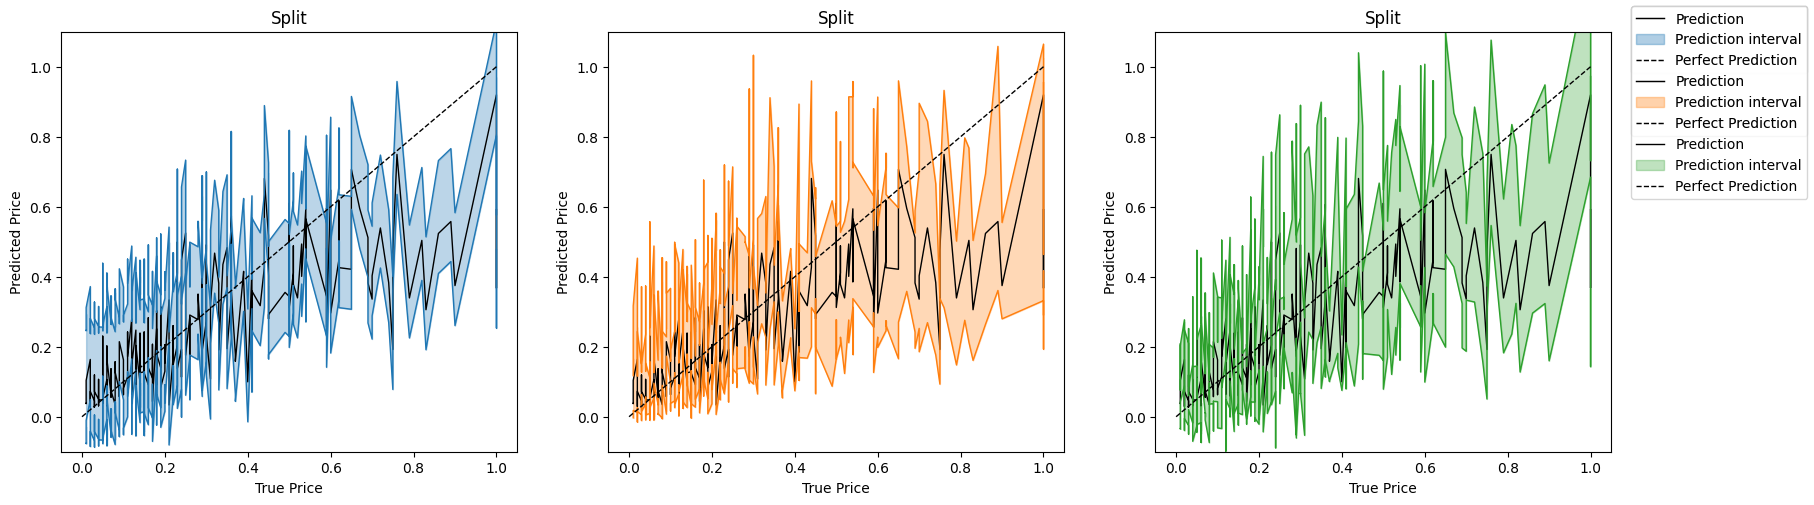

 20%|██        | 2/10 [00:04<00:16,  2.08s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 30%|███       | 3/10 [00:06<00:15,  2.21s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 40%|████      | 4/10 [00:08<00:12,  2.16s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 70%|███████   | 7/10 [00:16<00:07,  2.39s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 80%|████████  | 8/10 [00:18<00:04,  2.45s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
 90%|█████████ | 9/10 [00:20<00:02,  2.32s/it]INFO:root:The predictions are ill-sorted.
INFO:root:The predictions are ill-sorted.
100%|██████████| 10/10 [00:22<00:00,  2.24s/it]


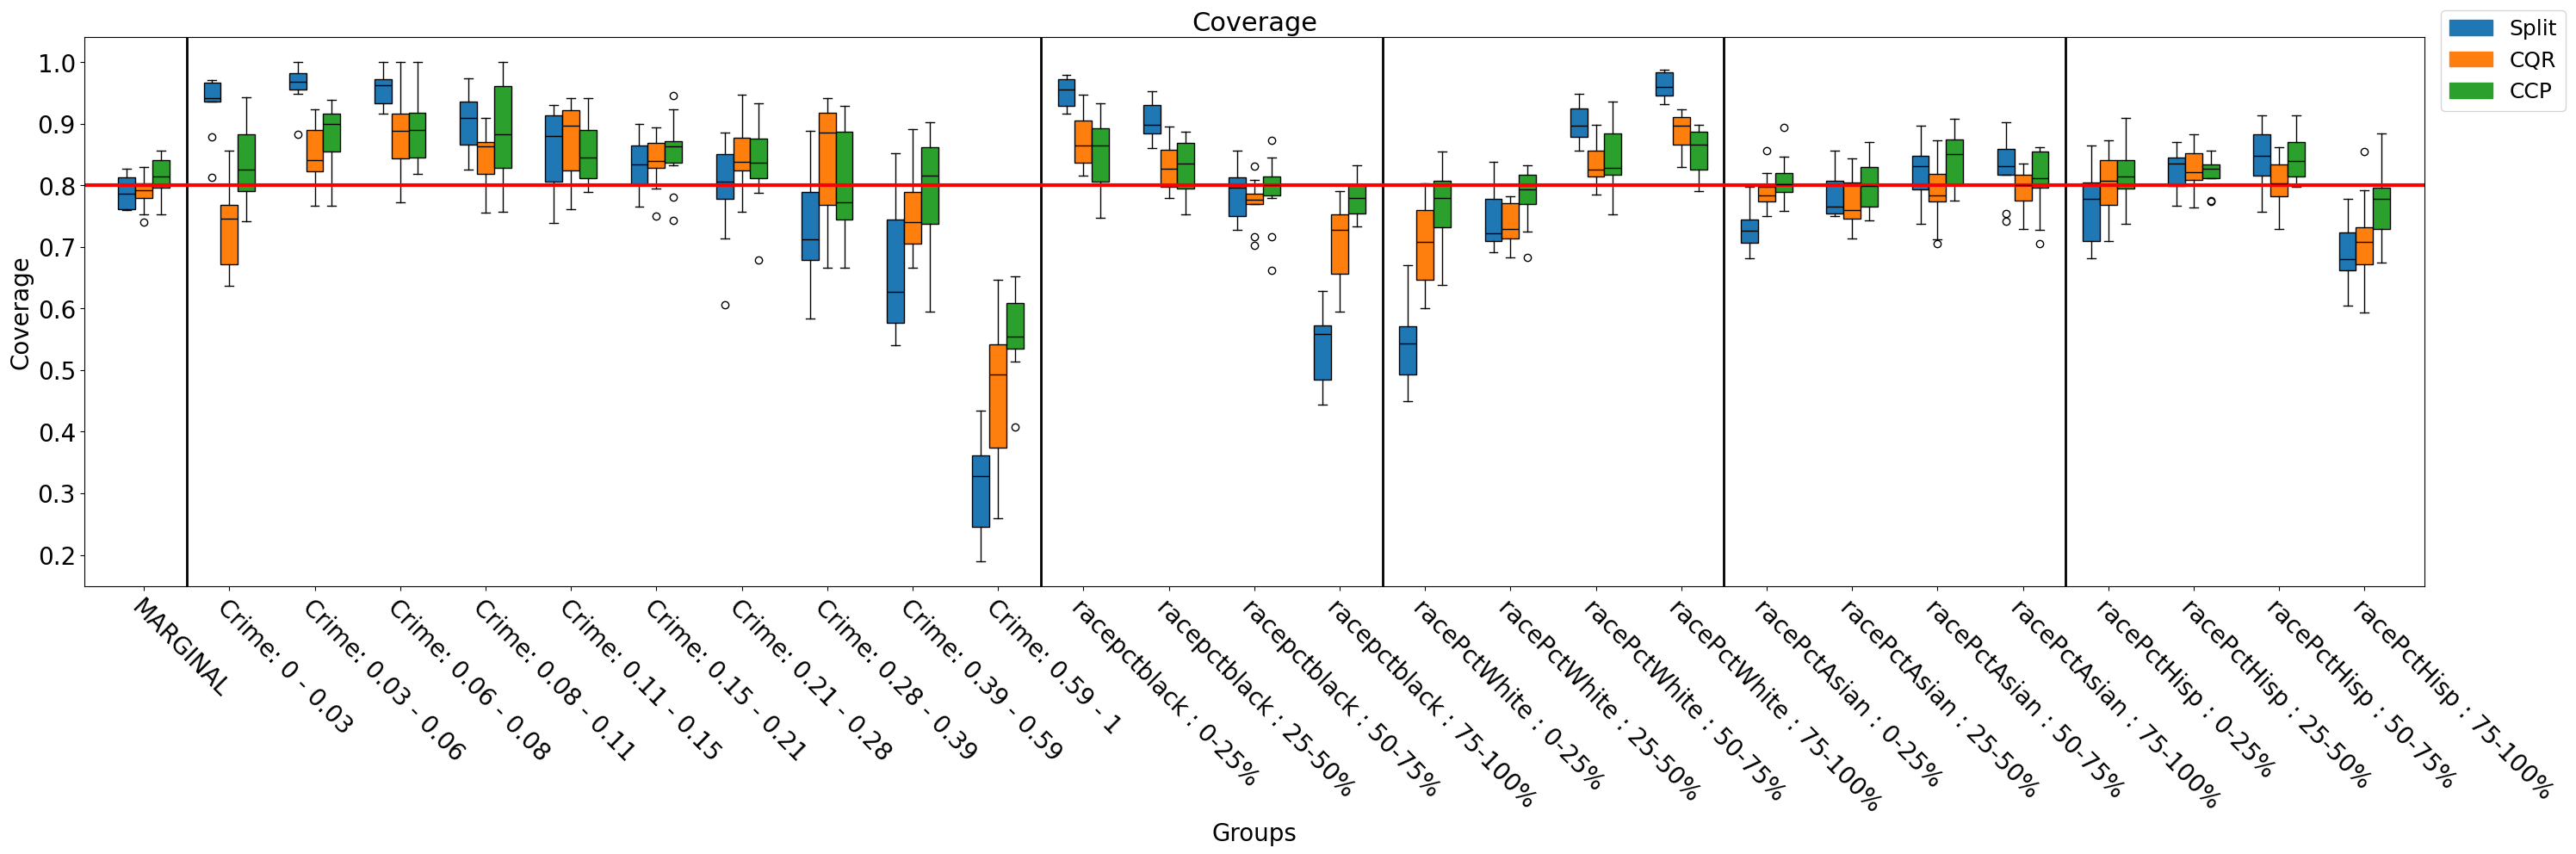

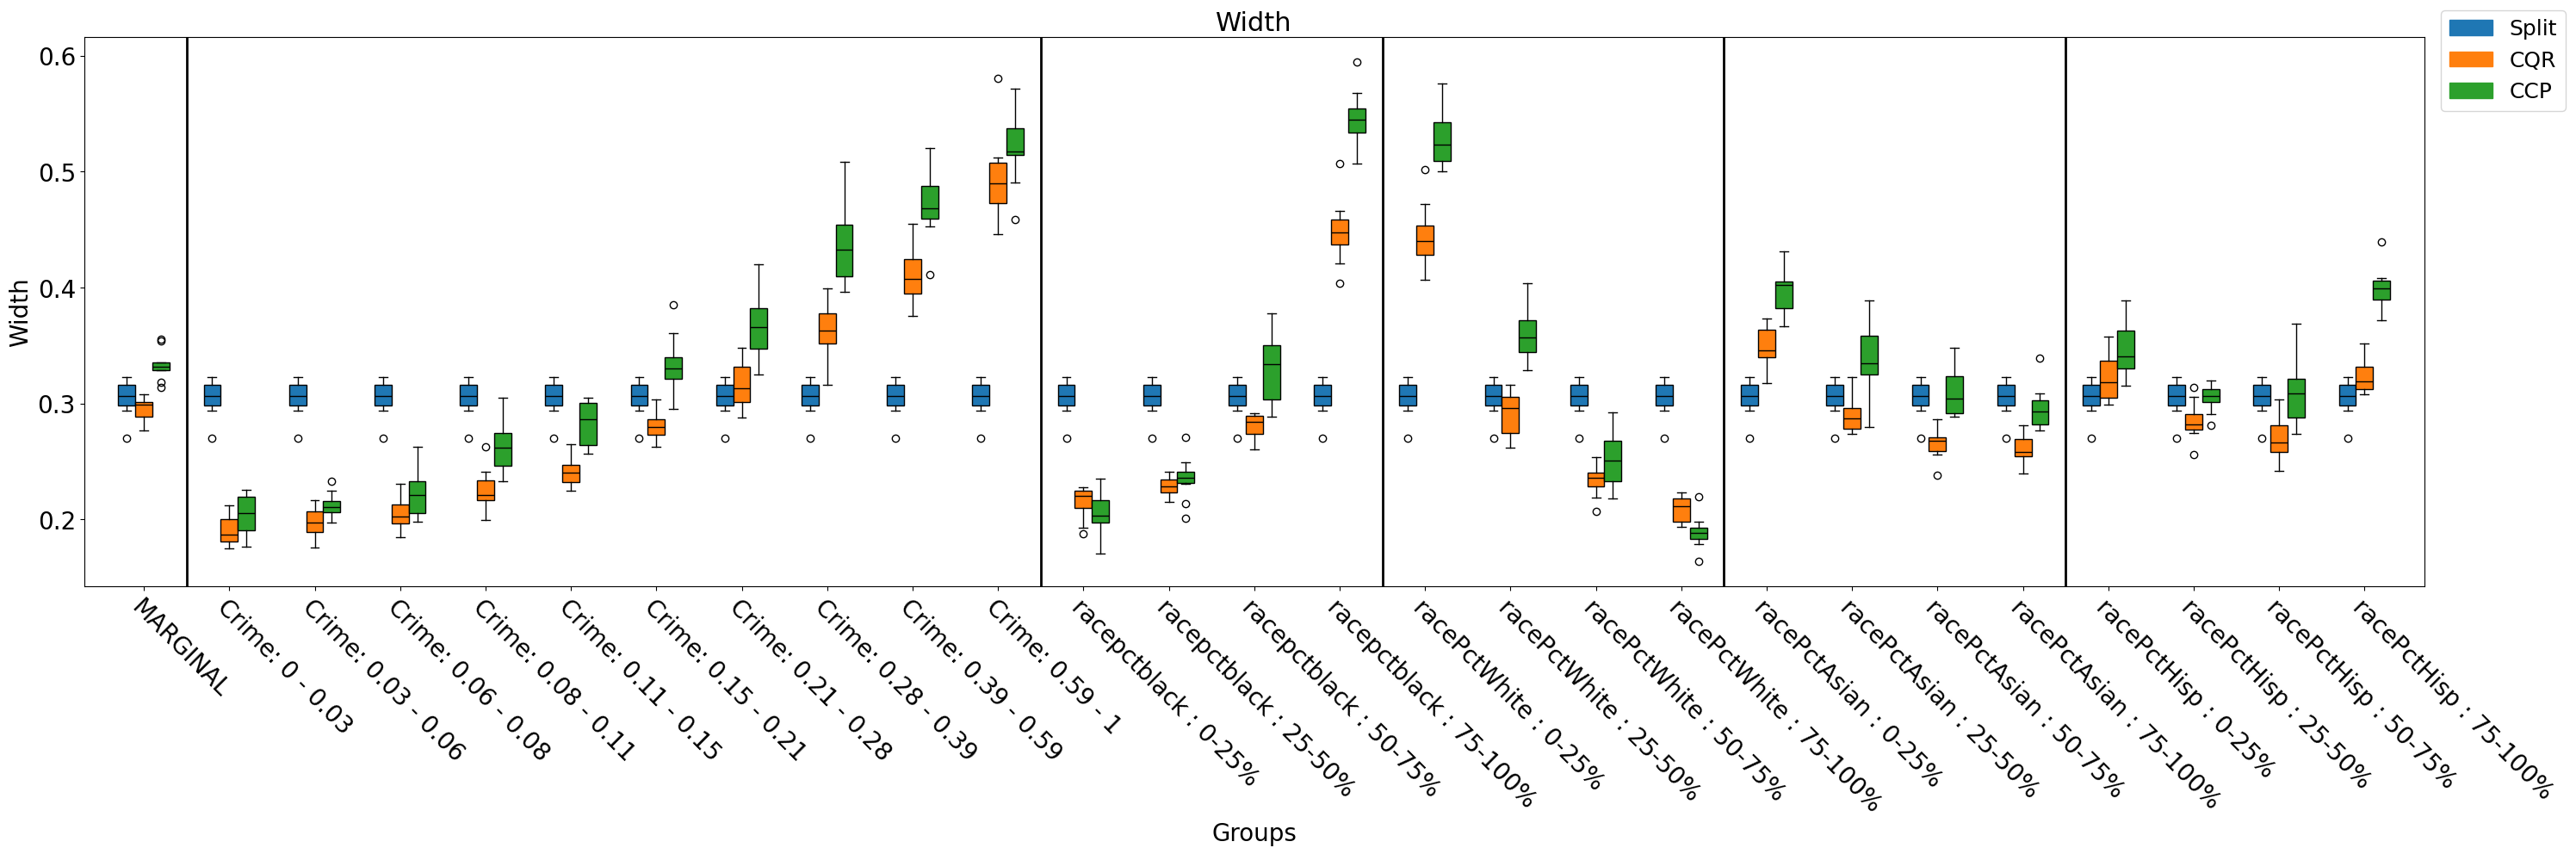

In [14]:
plot_intervals((mapie_split, mapie_cqr, mapie_ccp), n_train, n_calib, n_test)
plot_coverage_width((mapie_split, mapie_cqr, mapie_ccp), n_trials, group_functions, group_names, score_functions, score_names, n_train, n_calib, n_test)

As we expected, the coverage is now <u>homogenous on the ethnicity groups</u>. To achieve it, the prediction intervals are now even wider than before for previously under-covered samples, and smaller on previously over-covered samples. 

$\to$ The ``CCP`` method can guarantee a homogenous coverage on groups of interest (thus <u>remove bias</u>), by giving to the calibrator those groups, using ``CustomCCP`` calibrators.

$\to$ Fixing this bias, almost fixed the non-homogeneity of the coverage, on the target value.

<u>Next steps</u>: the only issue to achieve an almost perfect adaptativity, is to fix the under-coverage for the biggest 10% target crime values. One idea may be to combine the two approachs we used (with indicator functions to avoid the biases and gaussian kernels for overall adaptativity), or add a new column to the calibrator, with the ``y_pred`` value (example: adding ``Polynomial([4], variable="y_pred")``) to have a bigger interval for high predictions, without changing too much the smaller predictions.